In [ ]:
# Характеристика 

# Исследование нелинейного МНК

In [1]:
from testing import testing
import numpy as np
import matplotlib.pyplot as plt

## Иследование на количество итераций

Зависимотсть среднего критерия от числа итераций алгоритма. 

Бесшумные данные. 45 поворотов.

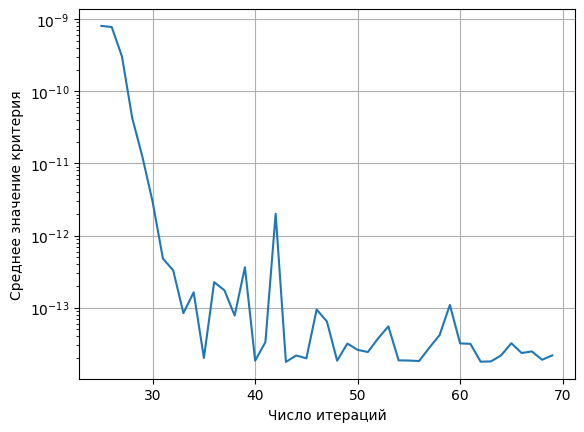

43


In [ ]:
iter_num = 70
model_num = 300

x = range(25, iter_num)
y = []

for i in x:
    res = 0
    for j in range(model_num):
        crit, rel = testing(1, 1, modeling_params=[2000, 0.01, 1500, 0], func_params=[i])
        res += crit
    res /= model_num
    y.append(res)

plt.plot(x, y)
plt.xlabel('Число итераций')
plt.ylabel('Среднее значение критерия')
plt.yscale('log')
plt.grid()
plt.show()

print(x[np.argmin(y)])

Зашумленные данные

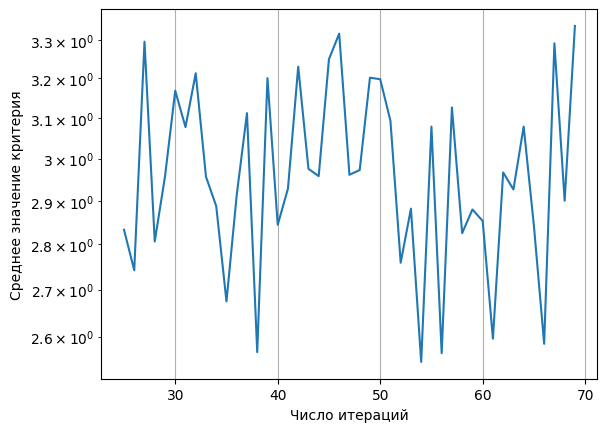

54


In [ ]:
iter_num = 70
model_num = 300

x = range(25, iter_num)
y = []

for i in x:
    res = 0
    for j in range(model_num):
        crit, rel = testing(1, 1, modeling_params=[2000, 0.01, 1500, 100], func_params=[i])
        res += crit
    res /= model_num
    y.append(res)

plt.plot(x, y)
plt.xlabel('Число итераций')
plt.ylabel('Среднее значение критерия')
plt.yscale('log')
plt.grid()
plt.show()

print(x[np.argmin(y)])

## Исследование стабильности критерия

Интервальный ряд критериев. Его статистические параметры.

Бесшумные данные. 45 поворотов. 30 итераций.

94
Выборочное мат. ожидание:  1.9834198328651943e-14
Выборочное СКО:  1.2907278602408198e-14


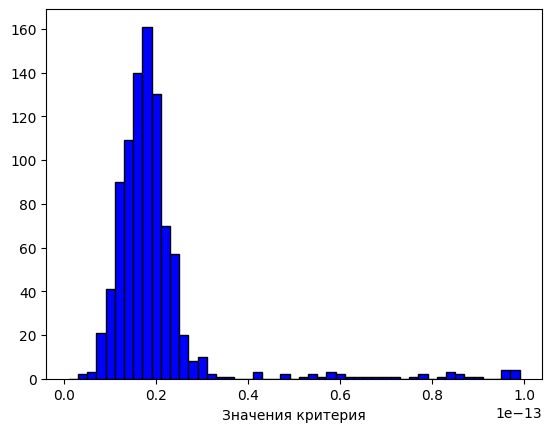

In [76]:
res = []
deads = 0
for j in range(1000):
    crit, rel = testing(1, 1, modeling_params=[2000, 0.01, 1500, 0], func_params=[35])
    if crit > 1e-13:
        deads += 1
        continue
    res.append(crit)

print(deads)

plt.hist(res, color='blue', edgecolor='black', bins=np.arange(1e-15, 1e-13, 2e-15))
# plt.xscale('log')
plt.xlabel('Значения критерия')

print('Выборочное мат. ожидание: ', np.mean(res))
print('Выборочное СКО: ', np.std(res))

Зашумленные данные

0
Выборочное мат. ожидание:  1.6797150157158325
Выборочное СКО:  1.9133386069306353


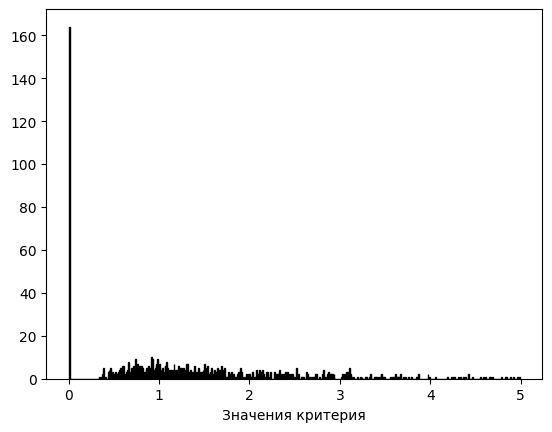

In [71]:
res = []
deads = 0
for j in range(1000):
    crit, rel = testing(1, 1, modeling_params=[2000, 0.01, 1500, 100], func_params=[35])
    # if crit > 1e-13:
    #     deads += 1
    #     continue
    res.append(crit)

print(deads)

plt.hist(res, color='blue', edgecolor='black', bins=np.arange(0, 5, 0.01))
# plt.xscale('log')
plt.xlabel('Значения критерия')

print('Выборочное мат. ожидание: ', np.mean(res))
print('Выборочное СКО: ', np.std(res))

## Исследование относительной ошибки коэффициентов

Безшумные данные

146 0.146


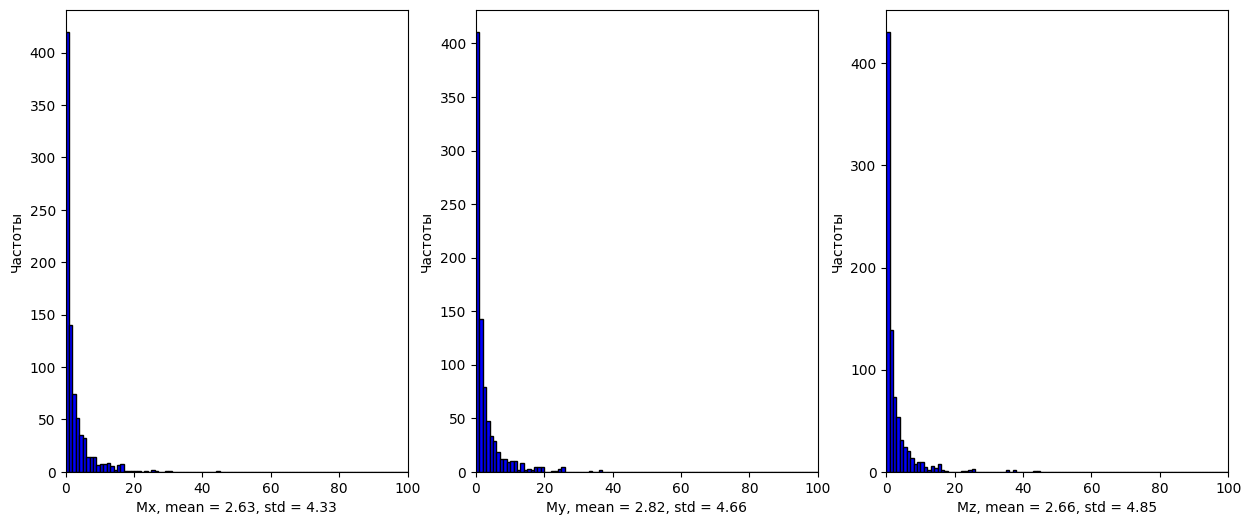

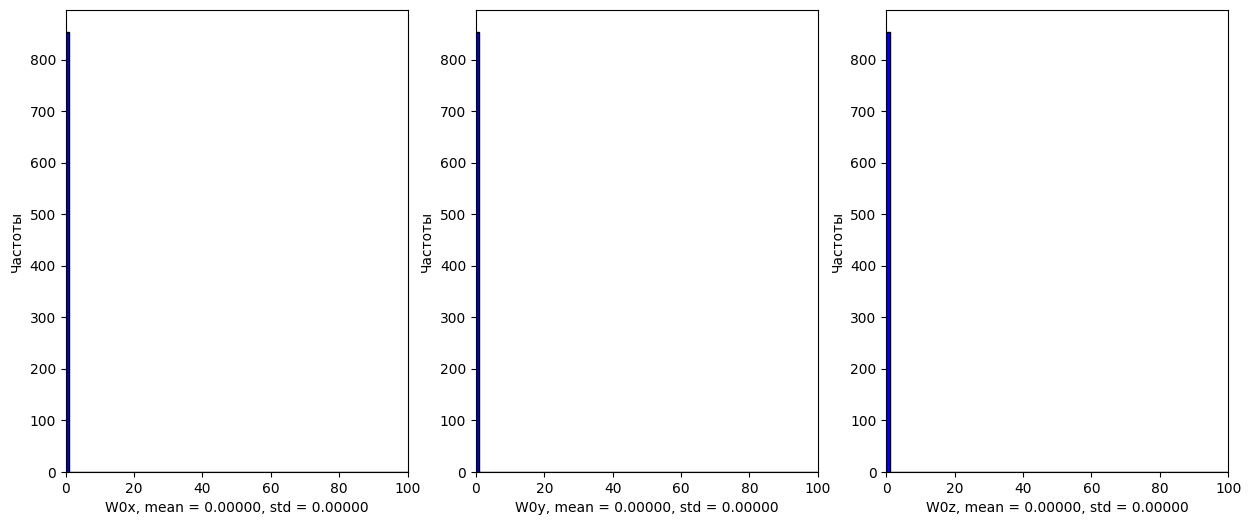

In [77]:
res = {
    'Mx': [],
    'My': [],
    'Mz': [],
    'W0x': [],
    'W0y': [],
    'W0z': []
}

axis_name = ['Mx', 'My', 'Mz', 'W0x', 'W0y', 'W0z']

n = 1000
deads = 0
for j in range(n):
    crit, rel = testing(1, 1, modeling_params=[2000, 0.01, 1500, 0], func_params=[35])
    if np.max(rel) > 100:
        deads += 1
        continue
    res['Mx'].append(rel[0])
    res['My'].append(rel[1])
    res['Mz'].append(rel[2])
    res['W0x'].append(rel[9])
    res['W0y'].append(rel[10])
    res['W0z'].append(rel[11])

print(deads, deads / n)

plt.figure(1, figsize=(15, 6))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    bins = np.arange(0, 101, 1)
    plt.hist(res[axis_name[i]], color='blue', edgecolor='black', bins=bins)
    plt.xlim(0, 100)
    plt.xlabel(f'{axis_name[i]}, mean = {np.mean(res[axis_name[i]]):.2f}, std = {np.std(res[axis_name[i]]):.2f}')
    plt.ylabel('Частоты')

plt.figure(2, figsize=(15, 6))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    bins = np.arange(0, 101, 1)
    plt.hist(res[axis_name[i+3]], color='blue', edgecolor='black', bins=bins)
    plt.xlim(0, 100)
    plt.xlabel(f'{axis_name[i+3]}, mean = {np.mean(res[axis_name[i+3]]):.5f}, std = {np.std(res[axis_name[i+3]]):.5f}')
    plt.ylabel('Частоты')

Зашумленные данные

231 0.231


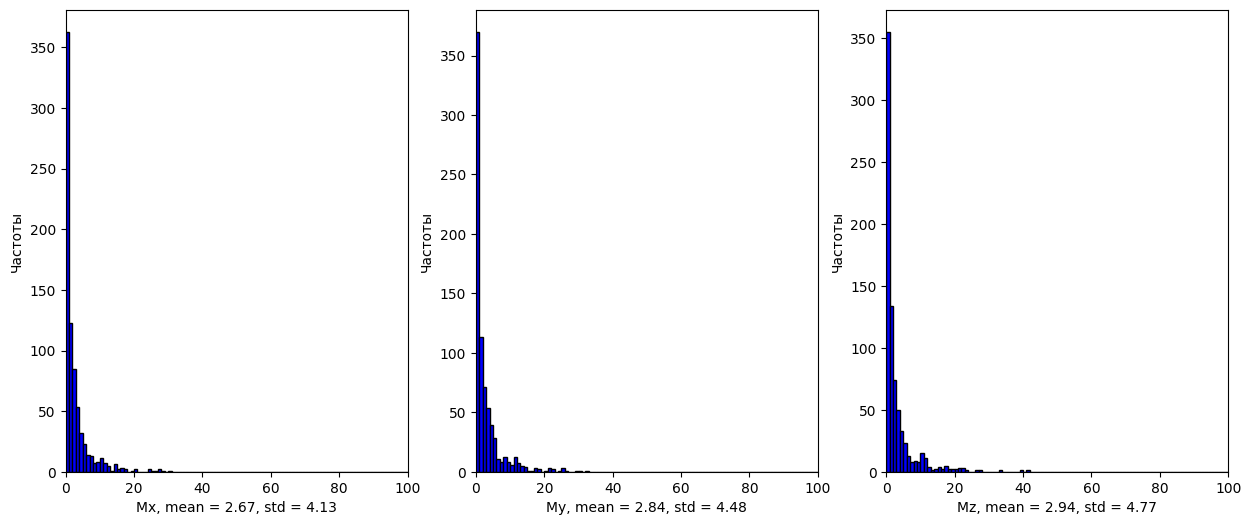

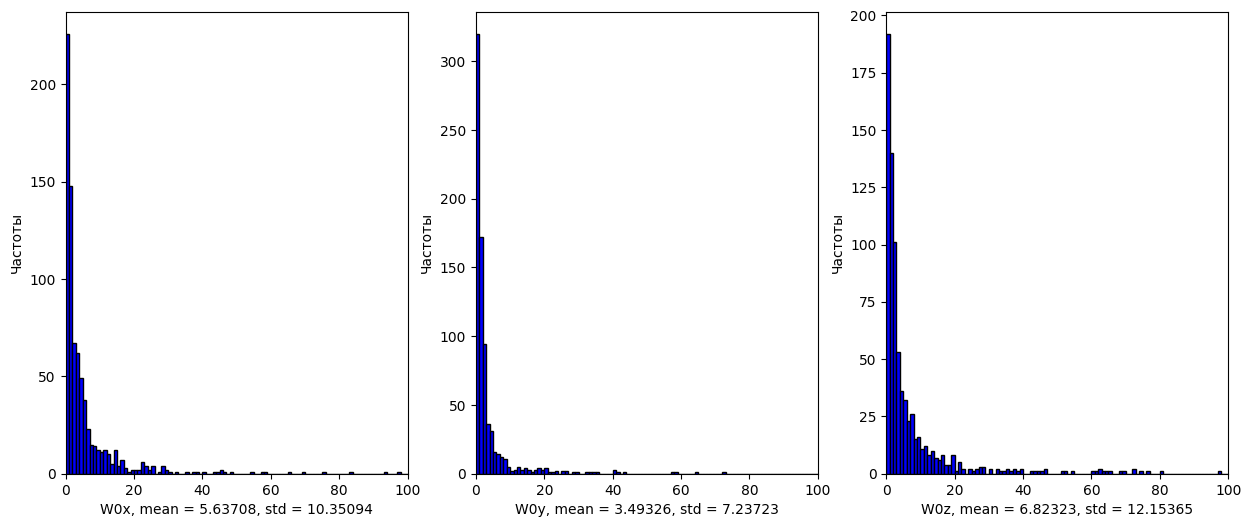

In [78]:
res = {
    'Mx': [],
    'My': [],
    'Mz': [],
    'W0x': [],
    'W0y': [],
    'W0z': []
}

axis_name = ['Mx', 'My', 'Mz', 'W0x', 'W0y', 'W0z']

n = 1000
deads = 0
for j in range(n):
    crit, rel = testing(1, 1, modeling_params=[2000, 0.01, 2000, 100], func_params=[35])
    if np.max(rel) > 100:
        deads += 1
        continue
    res['Mx'].append(rel[0])
    res['My'].append(rel[1])
    res['Mz'].append(rel[2])
    res['W0x'].append(rel[9])
    res['W0y'].append(rel[10])
    res['W0z'].append(rel[11])

print(deads, deads / n)

plt.figure(1, figsize=(15, 6))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    bins = np.arange(0, 101, 1)
    plt.hist(res[axis_name[i]], color='blue', edgecolor='black', bins=bins)
    plt.xlim(0, 100)
    plt.xlabel(f'{axis_name[i]}, mean = {np.mean(res[axis_name[i]]):.2f}, std = {np.std(res[axis_name[i]]):.2f}')
    plt.ylabel('Частоты')

plt.figure(2, figsize=(15, 6))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    bins = np.arange(0, 101, 1)
    plt.hist(res[axis_name[i+3]], color='blue', edgecolor='black', bins=bins)
    plt.xlim(0, 100)
    plt.xlabel(f'{axis_name[i+3]}, mean = {np.mean(res[axis_name[i+3]]):.5f}, std = {np.std(res[axis_name[i+3]]):.5f}')
    plt.ylabel('Частоты')